In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

gdf = gpd.read_file("../data/raw/data.gpkg")

# 2. Basic Inspection
print(f"Total polygons: {len(gdf)}")
print(f"Coordinate Reference System (CRS): {gdf.crs}")
print("\nFirst 5 rows to identify the class column:")
print(gdf.head())

Total polygons: 100271
Coordinate Reference System (CRS): EPSG:2056

First 5 rows to identify the class column:
   objectid lrtyp3code      lrtyp3text lrtyp2code      lrtyp2text lrtyp1code  \
0         1   01.00.00  Wald allgemein      01.00  Wald allgemein         01   
1         2   01.00.00  Wald allgemein      01.00  Wald allgemein         01   
2         3   01.00.00  Wald allgemein      01.00  Wald allgemein         01   
3         7   13.15.00       Baustelle      13.15       Baustelle         13   
4         8   13.15.00       Baustelle      13.15       Baustelle         13   

                                 lrtyp1text  biotoptypenqualitaet umsetzung  \
0                                    Wälder                     4     keine   
1                                    Wälder                     4     keine   
2                                    Wälder                     4     keine   
3  Gebäude-, Verkehrs- und Industrieflächen                     0     keine   
4  Gebäude-,

In [2]:
gdf.columns

Index(['objectid', 'lrtyp3code', 'lrtyp3text', 'lrtyp2code', 'lrtyp2text',
       'lrtyp1code', 'lrtyp1text', 'biotoptypenqualitaet', 'umsetzung',
       'versiegelung', 'feuchtigkeit', 'naehrstoffe', 'vernetzungstyp_offen',
       'vernetzungstyp_gehoelz', 'vernetzungstyp_trocken',
       'vernetzungstyp_feucht', 'vernetzungstyp_unbekannt', 'struktur_niedrig',
       'struktur_staudig', 'struktur_buesche', 'struktur_baeume',
       'struktur_keine', 'legende_lebensraeume', 'stand_ueberpruefung',
       'geometry'],
      dtype='str')

In [3]:
class_column = 'lrtyp2text'

gdf['area_sqm'] = gdf.geometry.area

class_stats = gdf.groupby(class_column).agg(
    total_area_sqm=('area_sqm', 'sum'),
    polygon_count=('geometry', 'count')
).reset_index()

class_stats = class_stats.sort_values(by='total_area_sqm', ascending=False)

print(class_stats.head(20))

                                           lrtyp2text  total_area_sqm  \
58                                     Wald allgemein    2.128404e+07   
9                                   Befestigte Fläche    1.264363e+07   
10  Biotopkomplexe und Nutzungstypen der bebauten ...    1.138379e+07   
24                 Grünanlage von Mehrfamilienhäusern    8.406465e+06   
26                                         Hausgarten    5.791873e+06   
56                                     Verkehrsfläche    5.772880e+06   
38                          Naturfernes Stillgewässer    3.465236e+06   
3                                 Artenarmes Grünland    3.279889e+06   
0                                               Acker    2.824704e+06   
35                                Mesophiles Grünland    2.462527e+06   
12      Einzelbaum/ Baumraster des  Siedlungsbereichs    1.791863e+06   
13                               Familiengartenanlage    1.554928e+06   
49                              Scher- und Trittras

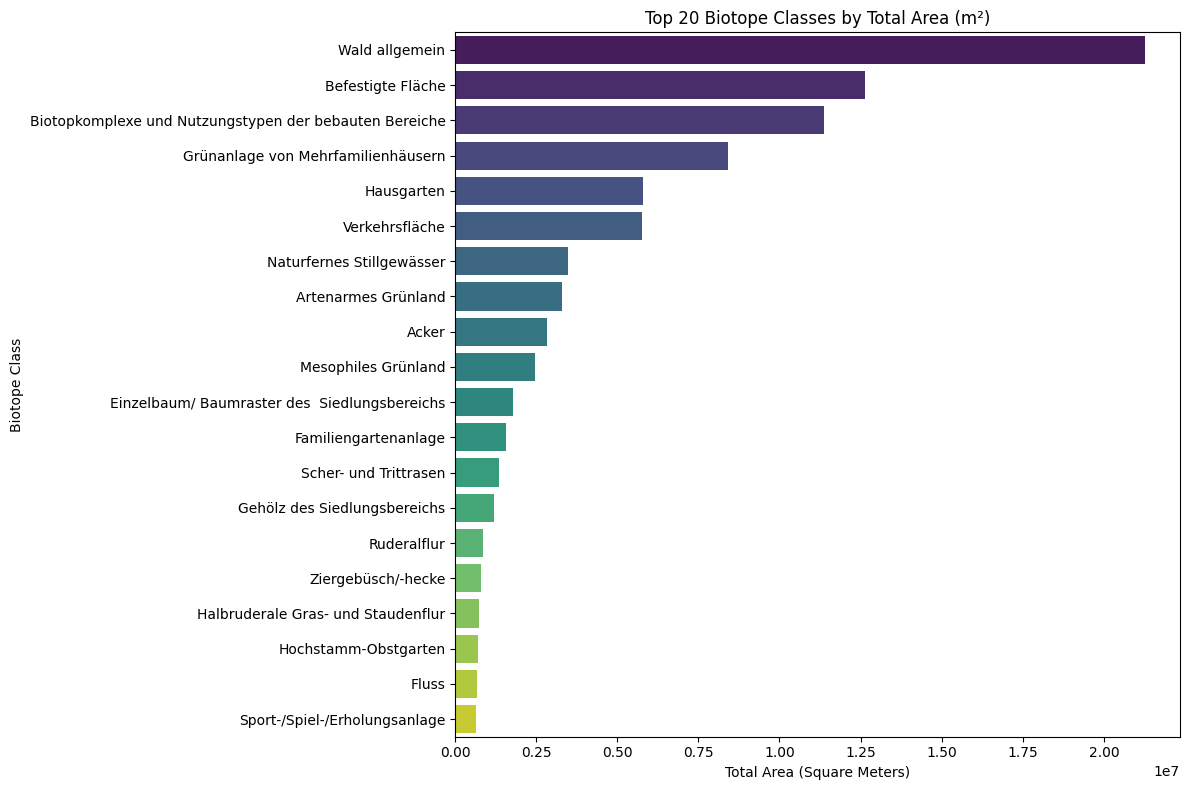

In [4]:
plt.figure(figsize=(12, 8))
sns.barplot(
    data=class_stats.head(20), 
    y=class_column, 
    x='total_area_sqm', 
    hue=class_column,
    palette='viridis',
    legend=False
)
plt.title('Top 20 Biotope Classes by Total Area (m²)')
plt.xlabel('Total Area (Square Meters)')
plt.ylabel('Biotope Class')
plt.tight_layout()
plt.show()

### Rationale for Class Aggregation

The original biotope dataset contains highly granular, expert-derived ecological classes. However, many of these categories (such as distinguishing between a "Family Garden" and a "Multi-Family House Garden," or various sub-types of meadows) are visually indistinguishable from top-down, 3-channel RGB aerial imagery. Furthermore, the exploratory data analysis reveals a severe class imbalance, with a long tail of extremely rare habitats. 

To formulate a viable supervised learning task and minimize spectral ambiguity for the segmentation model, we aggregate these fine-grained, land-use-based categories into 8 visually distinct and ecologically meaningful superclasses. This ensures the model has sufficient representative data to learn robust structural and textural features.

### Urban Habitat Superclass Groupings

**0: Impervious / Built-up**
* Befestigte Fläche
* Verkehrsfläche
* Biotopkomplexe und Nutzungstypen der bebauten ...

**1: Forest & Dense Canopy**
* Wald allgemein

**2: Urban Trees & Bushes**
* Einzelbaum/ Baumraster des  Siedlungsbereichs
* Gehölz des Siedlungsbereichs
* Ziergebüsch/-hecke

**3: Managed Green Spaces**
* Hausgarten
* Grünanlage von Mehrfamilienhäusern
* Familiengartenanlage
* Sport-/Spiel-/Erholungsanlage

**4: Standard Grassland**
* Scher- und Trittrasen
* Artenarmes Grünland

**5: Ecologically Valuable Meadow**
* Mesophiles Grünland
* Ruderalflur
* Halbruderale Gras- und Staudenflur

**6: Agriculture & Orchards**
* Acker
* Hochstamm-Obstgarten

**7: Water Bodies**
* Naturfernes Stillgewässer
* Fluss

In [5]:
class_mapping = {
    'Befestigte Fläche': 0,
    'Verkehrsfläche': 0,
    'Biotopkomplexe und Nutzungstypen der bebauten ...': 0,
    'Wald allgemein': 1,
    'Einzelbaum/ Baumraster des  Siedlungsbereichs': 2,
    'Gehölz des Siedlungsbereichs': 2,
    'Ziergebüsch/-hecke': 2,
    'Hausgarten': 3,
    'Grünanlage von Mehrfamilienhäusern': 3,
    'Familiengartenanlage': 3,
    'Sport-/Spiel-/Erholungsanlage': 3,
    'Scher- und Trittrasen': 4,
    'Artenarmes Grünland': 4,
    'Mesophiles Grünland': 5,
    'Ruderalflur': 5,
    'Halbruderale Gras- und Staudenflur': 5,
    'Acker': 6,
    'Hochstamm-Obstgarten': 6,
    'Naturfernes Stillgewässer': 7,
    'Fluss': 7
}

id_to_name = {
    0: 'Impervious / Built-up',
    1: 'Forest & Dense Canopy',
    2: 'Urban Trees & Bushes',
    3: 'Managed Green Spaces',
    4: 'Standard Grassland',
    5: 'Ecologically Valuable Meadow',
    6: 'Agriculture & Orchards',
    7: 'Water Bodies'
}

gdf['label_id'] = gdf['lrtyp2text'].map(class_mapping)

gdf_filtered = gdf.dropna(subset=['label_id']).copy()

gdf_filtered['label_id'] = gdf_filtered['label_id'].astype(int)

gdf_filtered['superclass_name'] = gdf_filtered['label_id'].map(id_to_name)

print("New Superclass Distribution (Polygon Count):")
print(gdf_filtered[['label_id', 'superclass_name']].value_counts().sort_index())

New Superclass Distribution (Polygon Count):
label_id  superclass_name             
0         Impervious / Built-up           20463
1         Forest & Dense Canopy            1116
2         Urban Trees & Bushes            16294
3         Managed Green Spaces            18869
4         Standard Grassland               3398
5         Ecologically Valuable Meadow     8548
6         Agriculture & Orchards            560
7         Water Bodies                      270
Name: count, dtype: int64


In [6]:
import os

os.makedirs("../data/processed", exist_ok=True)
export_path = "../data/processed/zuerich_biotopes_superclasses.gpkg"
gdf_filtered.to_file(export_path, driver="GPKG")

print(f"Exported data with {len(gdf_filtered)} polygons to {export_path}")

Exported data with 69518 polygons to ../data/processed/zuerich_biotopes_superclasses.gpkg
